# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Kadek Intan Dheya Pratiwi]
- **Email:** [Intandheya11@gmail.com]
- **ID Dicoding:** [CDCC014D6X1038]

## Menentukan Pertanyaan Bisnis

1. Pada kategori waktu apa (pagi, siang, sore, malam) rata-rata jumlah  
penyewaan sepeda per jam mencapai nilai tertinggi dan terendah selama periode 2011–2012, dan seberapa besar selisih rata-ratanya?

2. Berapa rata-rata jumlah penyewaan sepeda per jam pada setiap kondisi cuaca,
   dan kondisi cuaca mana yang menghasilkan rata-rata tertinggi serta terendah
   selama periode 2011–2012?

3. Berapa perbedaan rata-rata jumlah penyewaan sepeda harian antara hari kerja
   dan hari libur selama periode 2011–2012?

4. Berapa persentase hari dengan tingkat penggunaan tinggi (>4000 sewa/hari)
   selama periode 2011–2012, dan bagaimana distribusi ketiga kategori
   (Low, Medium, High) dapat digunakan untuk menentukan kebutuhan kapasitas
   armada harian?

## Import Semua Packages/Library yang Digunakan

In [28]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [29]:
# Load dataset day.csv
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset harian terdiri dari 731 baris data yang mencakup periode 2011–2012
Setiap baris merepresentasikan total penyewaan sepeda dalam satu hari penuh
Terlihat bahwa kolom dteday masih bertipe object dan beberapa kolom seperti season, weathersit, workingday masih berupa angka padahal bersifat kategorikal

In [30]:
# Load dataset hour.csv
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight**:
- Dataset per jam terdiri dari 17.379 baris data yang mencakup periode 2011–2012
Setiap baris merepresentasikan total penyewaan sepeda dalam satu jam pada hari tertentu
Terdapat kolom tambahan hr (jam 0–23) yang akan digunakan untuk analisis pola penyewaan berdasarkan waktu

### Assessing Data

#### Identifying ... problem

In [31]:
# 1. Cek tipe data - day_df
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [32]:
# 2. Cek tipe data - hour_df
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [33]:
# 3. Missing value - day_df
print("Missing value day_df:")
print(day_df.isna().sum())

Missing value day_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [34]:
# 4. Missing value - hour_df
print("Missing value hour_df:")
print(hour_df.isna().sum())

Missing value hour_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [35]:
# 5. Duplikasi - day_df
print("Duplikasi day_df:", day_df.duplicated().sum())

Duplikasi day_df: 0


In [36]:
# 6. Duplikasi - hour_df
print("Duplikasi hour_df:", hour_df.duplicated().sum())

Duplikasi hour_df: 0


In [37]:
# 7. Statistik deskriptif - day_df
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [38]:
# 8. Statistik deskriptif - hour_df
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [39]:
# 9. Nilai unik - day_df
day_df.nunique()

,0
instant,731
dteday,731
season,4
yr,2
mnth,12
holiday,2
weekday,7
workingday,2
weathersit,3
temp,499


In [40]:
# 10. Nilai unik - hour_df
hour_df.nunique()

,0
instant,17379
dteday,731
season,4
yr,2
mnth,12
hr,24
holiday,2
weekday,7
workingday,2
weathersit,4


**Insight:**
- Tidak ditemukan missing value maupun duplikasi pada kedua dataset. Namun terdapat beberapa hal yang perlu diperbaiki: (1) kolom dteday bertipe object dan perlu dikonversi ke datetime, (2) variabel seperti season, weathersit, workingday, dan holiday masih berupa numerik padahal bersifat kategorikal, (3) terdapat variasi besar pada kolom cnt yang mengindikasikan fluktuasi permintaan signifikan.

### Cleaning Data

#### Fixing ... problem

In [41]:
# Copy dataset untuk menjaga data asli
df_day = day_df.copy()
df_hour = hour_df.copy()

# Konversi tipe data tanggal
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

# Mapping season
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df_day['season'] = df_day['season'].map(season_map)
df_hour['season'] = df_hour['season'].map(season_map)

# Mapping year
yr_map = {0: '2011', 1: '2012'}
df_day['yr'] = df_day['yr'].map(yr_map)
df_hour['yr'] = df_hour['yr'].map(yr_map)

# Mapping weathersit
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
df_day['weathersit'] = df_day['weathersit'].map(weather_map)
df_hour['weathersit'] = df_hour['weathersit'].map(weather_map)

# Mapping workingday & holiday
df_day['workingday'] = df_day['workingday'].map({0: 'No', 1: 'Yes'})
df_hour['workingday'] = df_hour['workingday'].map({0: 'No', 1: 'Yes'})
df_day['holiday'] = df_day['holiday'].map({0: 'No', 1: 'Yes'})
df_hour['holiday'] = df_hour['holiday'].map({0: 'No', 1: 'Yes'})

# Mapping weekday
weekday_map = {
    0: 'Sunday', 1: 'Monday', 2: 'Tuesday',
    3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'
}
df_day['weekday'] = df_day['weekday'].map(weekday_map)
df_hour['weekday'] = df_hour['weekday'].map(weekday_map)

# Tambah kolom kategori waktu (khusus hour)
def categorize_time(hour):
    if 5 <= hour < 11:
        return 'Morning'
    elif 11 <= hour < 15:
        return 'Afternoon'
    elif 15 <= hour < 19:
        return 'Evening'
    else:
        return 'Night'

df_hour['time_category'] = df_hour['hr'].apply(categorize_time)

print("Cleaning selesai!")

Cleaning selesai!


In [42]:
# Verifikasi hasil cleaning - day
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,No,Saturday,No,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,No,Sunday,No,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,No,Monday,Yes,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,No,Tuesday,Yes,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,No,Wednesday,Yes,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [43]:
# Verifikasi hasil cleaning - hour
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,time_category
0,1,2011-01-01,Spring,2011,1,0,No,Saturday,No,Clear,0.24,0.2879,0.81,0.0,3,13,16,Night
1,2,2011-01-01,Spring,2011,1,1,No,Saturday,No,Clear,0.22,0.2727,0.80,0.0,8,32,40,Night
2,3,2011-01-01,Spring,2011,1,2,No,Saturday,No,Clear,0.22,0.2727,0.80,0.0,5,27,32,Night
3,4,2011-01-01,Spring,2011,1,3,No,Saturday,No,Clear,0.24,0.2879,0.75,0.0,3,10,13,Night
4,5,2011-01-01,Spring,2011,1,4,No,Saturday,No,Clear,0.24,0.2879,0.75,0.0,0,1,1,Night


**Insight:**
- Proses cleaning berhasil mengkonversi dteday ke datetime, memetakan variabel kategorikal ke label yang lebih informatif, serta menambahkan kolom time_category untuk analisis pola waktu. Data siap digunakan untuk tahap EDA.

## Exploratory Data Analysis (EDA)

### Explore ...

In [44]:
# Q1: Rata-rata penyewaan per kategori waktu
print("Rata-rata penyewaan berdasarkan kategori waktu:")
df_hour.groupby('time_category')['cnt'].mean().sort_values(ascending=False)

Rata-rata penyewaan berdasarkan kategori waktu:


,cnt
time_category,
Evening,362.539938
Afternoon,239.033642
Morning,177.071264
Night,106.762745


**insight:**

Evening (sore) memiliki rata-rata penyewaan tertinggi, diikuti Morning (pagi)
Pola ini menunjukkan adanya dua periode puncak yang berkaitan dengan aktivitas commuting (berangkat & pulang kerja)
Night memiliki rata-rata terendah karena minimnya aktivitas mobilitas pada dini hari hingga subuh

In [45]:
# Q2: Rata-rata penyewaan per kondisi cuaca
print("Rata-rata penyewaan berdasarkan kondisi cuaca:")
df_hour.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)

Rata-rata penyewaan berdasarkan kondisi cuaca:


,cnt
weathersit,
Clear,204.869272
Mist,175.165493
Light Rain/Snow,111.579281
Heavy Rain/Snow,74.333333


**insight:**

Cuaca Clear menghasilkan rata-rata penyewaan tertinggi, sementara Heavy Rain/Snow menghasilkan yang terendah
Terdapat penurunan yang konsisten seiring memburuknya kondisi cuaca
Hal ini mengindikasikan bahwa cuaca merupakan faktor eksternal yang sangat berpengaruh terhadap keputusan pengguna untuk menyewa sepeda

In [46]:
# Q3: Rata-rata penyewaan hari kerja vs hari libur
print("Rata-rata penyewaan: Hari Kerja vs Hari Libur:")
df_day.groupby('workingday')['cnt'].mean()

Rata-rata penyewaan: Hari Kerja vs Hari Libur:


,cnt
workingday,
No,4330.168831
Yes,4584.820000


**insight:**

Rata-rata penyewaan pada hari kerja lebih tinggi dibandingkan hari libur
Perbedaan ini mengindikasikan bahwa sepeda lebih banyak digunakan sebagai moda transportasi rutin daripada untuk aktivitas rekreasi
Temuan ini konsisten dengan pola double-peak yang ditemukan pada analisis kategori waktu

In [47]:
# Q4: Distribusi frekuensi berdasarkan kategori waktu dan hari kerja
print("Pola penggunaan per kategori waktu dan jenis hari:")
df_hour.groupby(['workingday', 'time_category'])['cnt'].mean().unstack()

Pola penggunaan per kategori waktu dan jenis hari:


time_category,Afternoon,Evening,Morning,Night
workingday,,,,
No,354.738095,329.088841,101.392000,100.055846
Yes,185.282554,378.024072,212.049076,109.895455


**Insight:**

Pada hari kerja, Evening dan Morning mendominasi dengan rata-rata penyewaan tertinggi — mencerminkan pola commuting yang kuat
Pada hari libur, distribusi penyewaan lebih merata sepanjang hari dengan puncak pada Afternoon
Perbedaan pola ini menunjukkan bahwa perilaku pengguna di hari kerja dan hari libur berbeda secara signifikan, sehingga strategi pengelolaan armada perlu disesuaikan untuk masing-masing kondisi

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pola Berdasarkan Kategori Waktu

/tmp/ipykernel_2887/3217239805.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


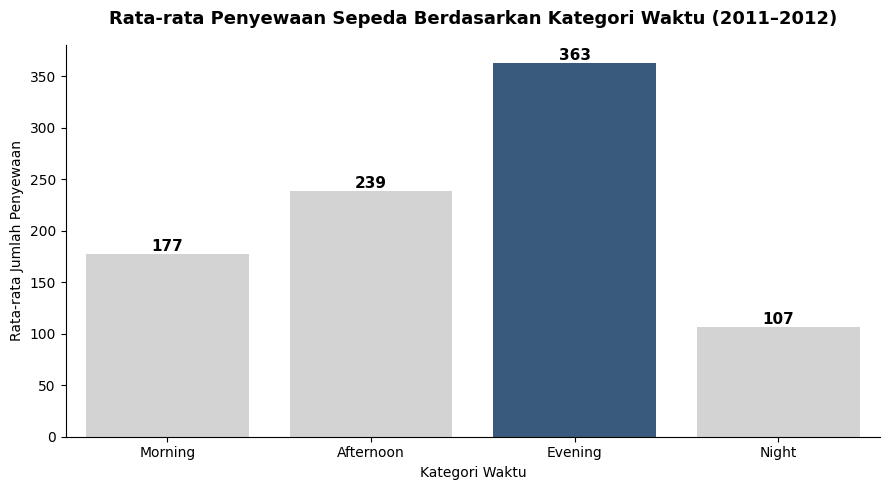

In [48]:
# Pertanyaan 1: Pola berdasarkan Kategori Waktu
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_usage = df_hour.groupby('time_category')['cnt'].mean().reindex(time_order).reset_index()

plt.figure(figsize=(9, 5))
bars = sns.barplot(
    data=time_usage,
    x='time_category',
    y='cnt',
    palette=['#2E5A88' if v == time_usage['cnt'].max() else '#D3D3D3' for v in time_usage['cnt']]
)

for p in bars.patches:
    bars.annotate(f'{p.get_height():.0f}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kategori Waktu (2011–2012)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Kategori Waktu')
plt.ylabel('Rata-rata Jumlah Penyewaan')
sns.despine()
plt.tight_layout()
plt.show()

**insight:**

Penyewaan tertinggi terjadi pada Evening (sore), diikuti Morning (pagi). Pola double-peak ini mengindikasikan dominasi penggunaan untuk commuting. Night menjadi periode terendah karena aktivitas mobilitas menurun drastis.

### Pertanyaan 2: Pengaruh Kondisi Cuaca

/tmp/ipykernel_2887/1900304386.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars2 = sns.barplot(


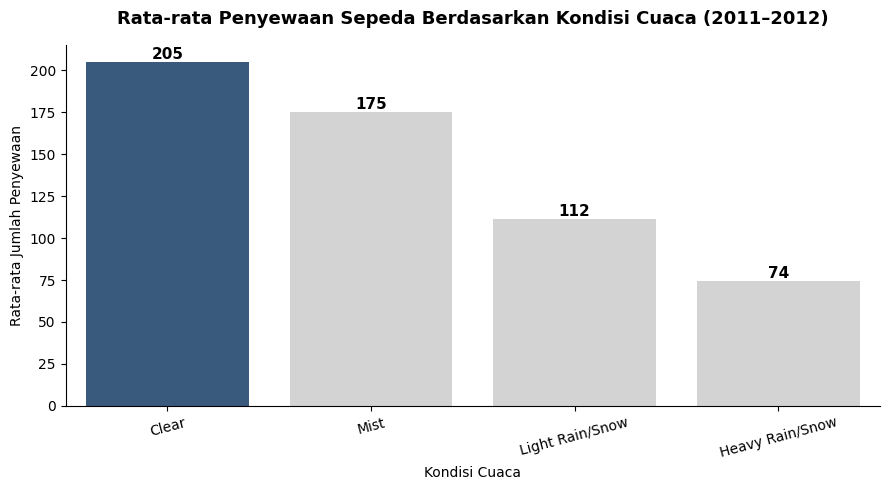

In [49]:
# --- Pertanyaan 2: Pengaruh Kondisi Cuaca ---
weather_usage = df_hour.groupby('weathersit')['cnt'].mean().reset_index()
weather_usage = weather_usage.sort_values('cnt', ascending=False)

plt.figure(figsize=(9, 5))
bars2 = sns.barplot(
    data=weather_usage,
    x='weathersit',
    y='cnt',
    palette=['#2E5A88' if i == 0 else '#D3D3D3' for i in range(len(weather_usage))]
)

for p in bars2.patches:
    bars2.annotate(f'{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca (2011–2012)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks(rotation=15)
sns.despine()
plt.tight_layout()
plt.show()

**Insight:**

-Cuaca Clear menghasilkan rata-rata penyewaan tertinggi, sedangkan Heavy Rain/Snow menghasilkan yang terendah. Semakin buruk kondisi cuaca, semakin signifikan penurunan jumlah penyewaan — menunjukkan cuaca sebagai faktor eksternal utama.

## Pertanyaan 3 : Hari Kerja vs Hari Libur

/tmp/ipykernel_2887/1052596619.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars3 = sns.barplot(


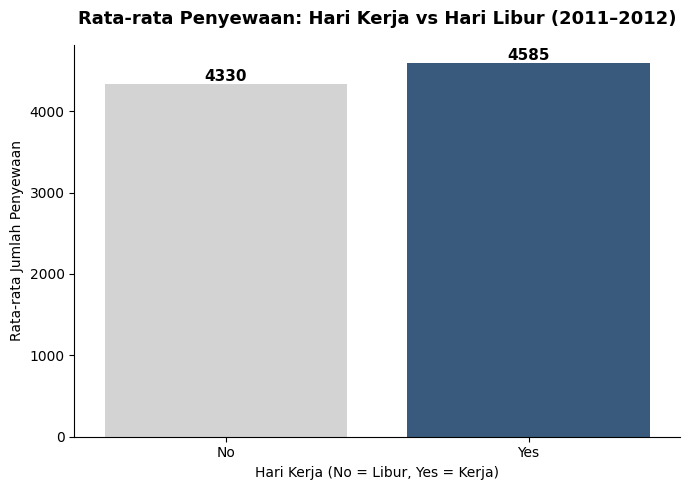

In [50]:
# --- Pertanyaan 3: Hari Kerja vs Hari Libur ---
working_usage = df_day.groupby('workingday')['cnt'].mean().reset_index()

plt.figure(figsize=(7, 5))
bars3 = sns.barplot(
    data=working_usage,
    x='workingday',
    y='cnt',
    palette=['#D3D3D3', '#2E5A88']
)

for p in bars3.patches:
    bars3.annotate(f'{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Rata-rata Penyewaan: Hari Kerja vs Hari Libur (2011–2012)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Hari Kerja (No = Libur, Yes = Kerja)')
plt.ylabel('Rata-rata Jumlah Penyewaan')
sns.despine()
plt.tight_layout()
plt.show()

insight:

Hari kerja memiliki rata-rata penyewaan lebih tinggi dibanding hari libur, menegaskan bahwa sepeda lebih banyak digunakan untuk kebutuhan transportasi rutin daripada rekreasi.

Pertanyaan 4 : Distribusi Tingkat Penggunaan

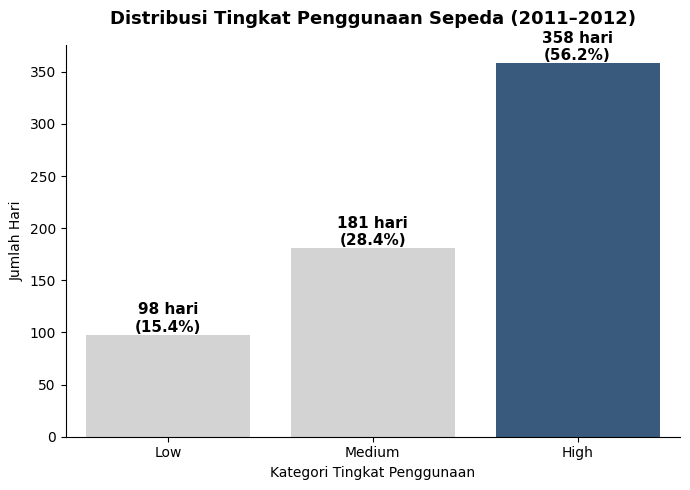

In [51]:
# --- Pertanyaan 4: Distribusi Tingkat Penggunaan ---
df_day['usage_level'] = pd.cut(
    df_day['cnt'],
    bins=[0, 2000, 4000, 7000],
    labels=['Low', 'Medium', 'High']
)

usage_dist = df_day['usage_level'].value_counts().reindex(['Low', 'Medium', 'High']).reset_index()
usage_dist.columns = ['usage_level', 'count']

plt.figure(figsize=(7, 5))
colors_map = {'Low': '#D3D3D3', 'Medium': '#D3D3D3', 'High': '#2E5A88'}
bars4 = sns.barplot(
    data=usage_dist,
    x='usage_level',
    y='count',
    hue='usage_level',
    palette=colors_map,
    legend=False
)

total_days = usage_dist['count'].sum()
for p in bars4.patches:
    pct = p.get_height() / total_days * 100
    bars4.annotate(f'{int(p.get_height())} hari\n({pct:.1f}%)',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribusi Tingkat Penggunaan Sepeda (2011–2012)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Kategori Tingkat Penggunaan')
plt.ylabel('Jumlah Hari')
sns.despine()
plt.tight_layout()
plt.show()

Insight :

Mayoritas hari berada pada kategori High dan Medium, menunjukkan permintaan layanan bike sharing yang secara konsisten tinggi sepanjang 2011–2012. Kategori Low sangat sedikit, artinya hari dengan penyewaan rendah merupakan pengecualian.

Analisis Lanjutan (Clustering/Binning)

In [52]:
# Tujuan: Mengelompokkan jam operasional ke dalam kategori intensitas penggunaan
# untuk mengidentifikasi jam-jam kritis yang membutuhkan ketersediaan armada lebih banyak.

hourly_avg = df_hour.groupby('hr')['cnt'].mean().reset_index()
hourly_avg.columns = ['hr', 'avg_cnt']

# Binning manual berdasarkan rata-rata penyewaan per jam
hourly_avg['demand_level'] = pd.cut(
    hourly_avg['avg_cnt'],
    bins=[0, 100, 250, 500],
    labels=['Low Demand', 'Medium Demand', 'High Demand']
)

print("Distribusi Jam berdasarkan Level Demand:")
print(hourly_avg.groupby('demand_level', observed=True)['hr'].apply(list))

Distribusi Jam berdasarkan Level Demand:
demand_level
Low Demand             [0, 1, 2, 3, 4, 5, 6, 23]
Medium Demand     [7, 9, 10, 11, 14, 20, 21, 22]
High Demand      [8, 12, 13, 15, 16, 17, 18, 19]
Name: hr, dtype: object


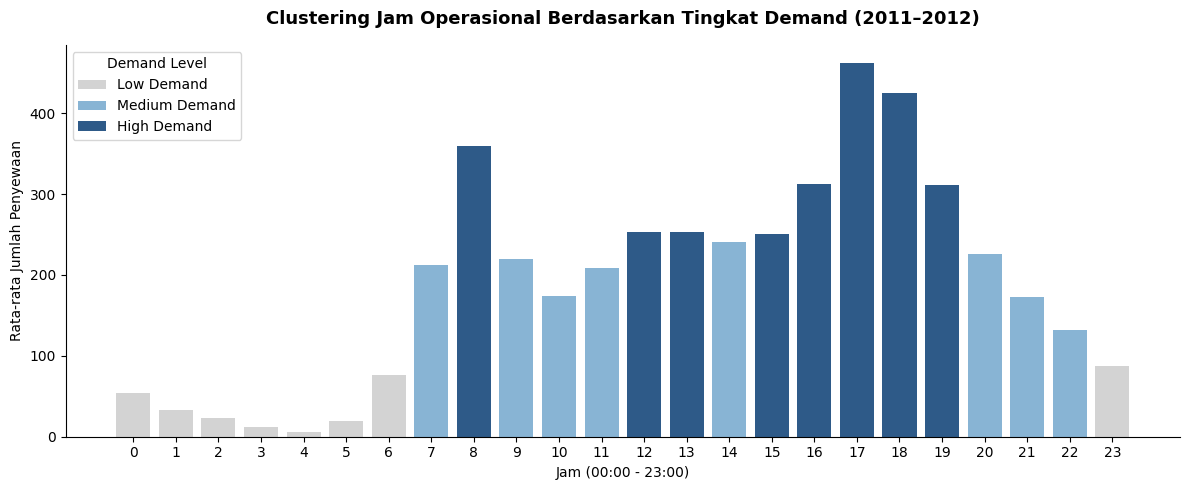

In [53]:
# Visualisasi hasil clustering jam berdasarkan demand level
color_map = {
    'Low Demand': '#D3D3D3',
    'Medium Demand': '#88B4D4',
    'High Demand': '#2E5A88'
}

plt.figure(figsize=(12, 5))
bar_colors = [color_map[level] for level in hourly_avg['demand_level'].astype(str)]

plt.bar(hourly_avg['hr'], hourly_avg['avg_cnt'], color=bar_colors)

# Tambah legend manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
plt.legend(handles=legend_elements, title='Demand Level', loc='upper left')

plt.title('Clustering Jam Operasional Berdasarkan Tingkat Demand (2011–2012)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Jam (00:00 - 23:00)')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks(range(0, 24))
sns.despine()
plt.tight_layout()
plt.show()

## Insight Analisis Lanjutan:

Teknik binning manual digunakan untuk mengelompokkan 24 jam operasional ke dalam tiga kategori demand: Low (rata-rata < 100), Medium (100–250), dan High (>250). Hasil clustering menunjukkan bahwa jam dengan demand tertinggi terkonsentrasi pada pagi (07:00–09:00) dan sore (16:00–19:00), sedangkan dini hari (00:00–05:00) masuk kategori Low Demand. Informasi ini dapat digunakan tim operasional untuk mengoptimalkan distribusi dan rotasi armada sepeda secara efisien.

## Conclusion :

### Pertanyaan 1 — Pola Penyewaan Berdasarkan Kategori Waktu
Penyewaan sepeda tertinggi terjadi pada Evening dan Morning, membentuk pola double-peak
yang khas dari aktivitas commuting. Night menjadi periode terendah selama 2011–2012.

### Pertanyaan 2 — Pengaruh Kondisi Cuaca
Cuaca Clear menghasilkan rata-rata penyewaan tertinggi. Semakin buruk cuaca,
semakin besar penurunan penyewaan. Cuaca terbukti sebagai faktor eksternal utama
yang mempengaruhi demand selama 2011–2012.

### Pertanyaan 3 — Hari Kerja vs Hari Libur
Hari kerja memiliki rata-rata penyewaan lebih tinggi dari hari libur,
menunjukkan dominasi penggunaan sepeda untuk transportasi rutin dibanding rekreasi.

### Pertanyaan 4 — Distribusi Tingkat Penggunaan
Mayoritas hari berada pada kategori Medium–High usage, menandakan permintaan
layanan bike sharing yang stabil dan tinggi sepanjang periode pengamatan.

**Rekomendasi Action Item:**


1. **Optimalkan distribusi armada pada jam sibuk (07:00–09:00 & 16:00–19:00)**
   berdasarkan hasil clustering demand level, untuk menghindari kekurangan unit
   saat permintaan puncak.

2. **Siapkan protokol cuaca buruk** — kurangi armada di titik tertentu dan alihkan
   ke area indoor/parkir saat hujan diprediksi, mengingat penurunan demand yang
   signifikan pada kondisi Light Rain/Snow.

3. **Buat program insentif khusus hari libur** (misalnya diskon atau paket wisata)
   untuk meningkatkan penyewaan pada hari-hari dengan demand yang lebih rendah
   dibanding hari kerja.